INFO GENERALI
Righe: 587  |  Colonne: 17
<class 'pandas.DataFrame'>
RangeIndex: 587 entries, 0 to 586
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_key                 587 non-null    int64  
 1   nome_completo                587 non-null    str    
 2   eta                          587 non-null    int64  
 3   paese                        587 non-null    str    
 4   sesso                        587 non-null    str    
 5   tenure_giorni                587 non-null    int64  
 6   recency_giorni               587 non-null    int64  
 7   frequency                    587 non-null    int64  
 8   monetary                     587 non-null    str    
 9   frequency_normalizzata       587 non-null    float64
 10  regolarita_acquisti          587 non-null    str    
 11  regolarita_non_calcolabile   587 non-null    int64  
 12  aov                          587 non-null    str

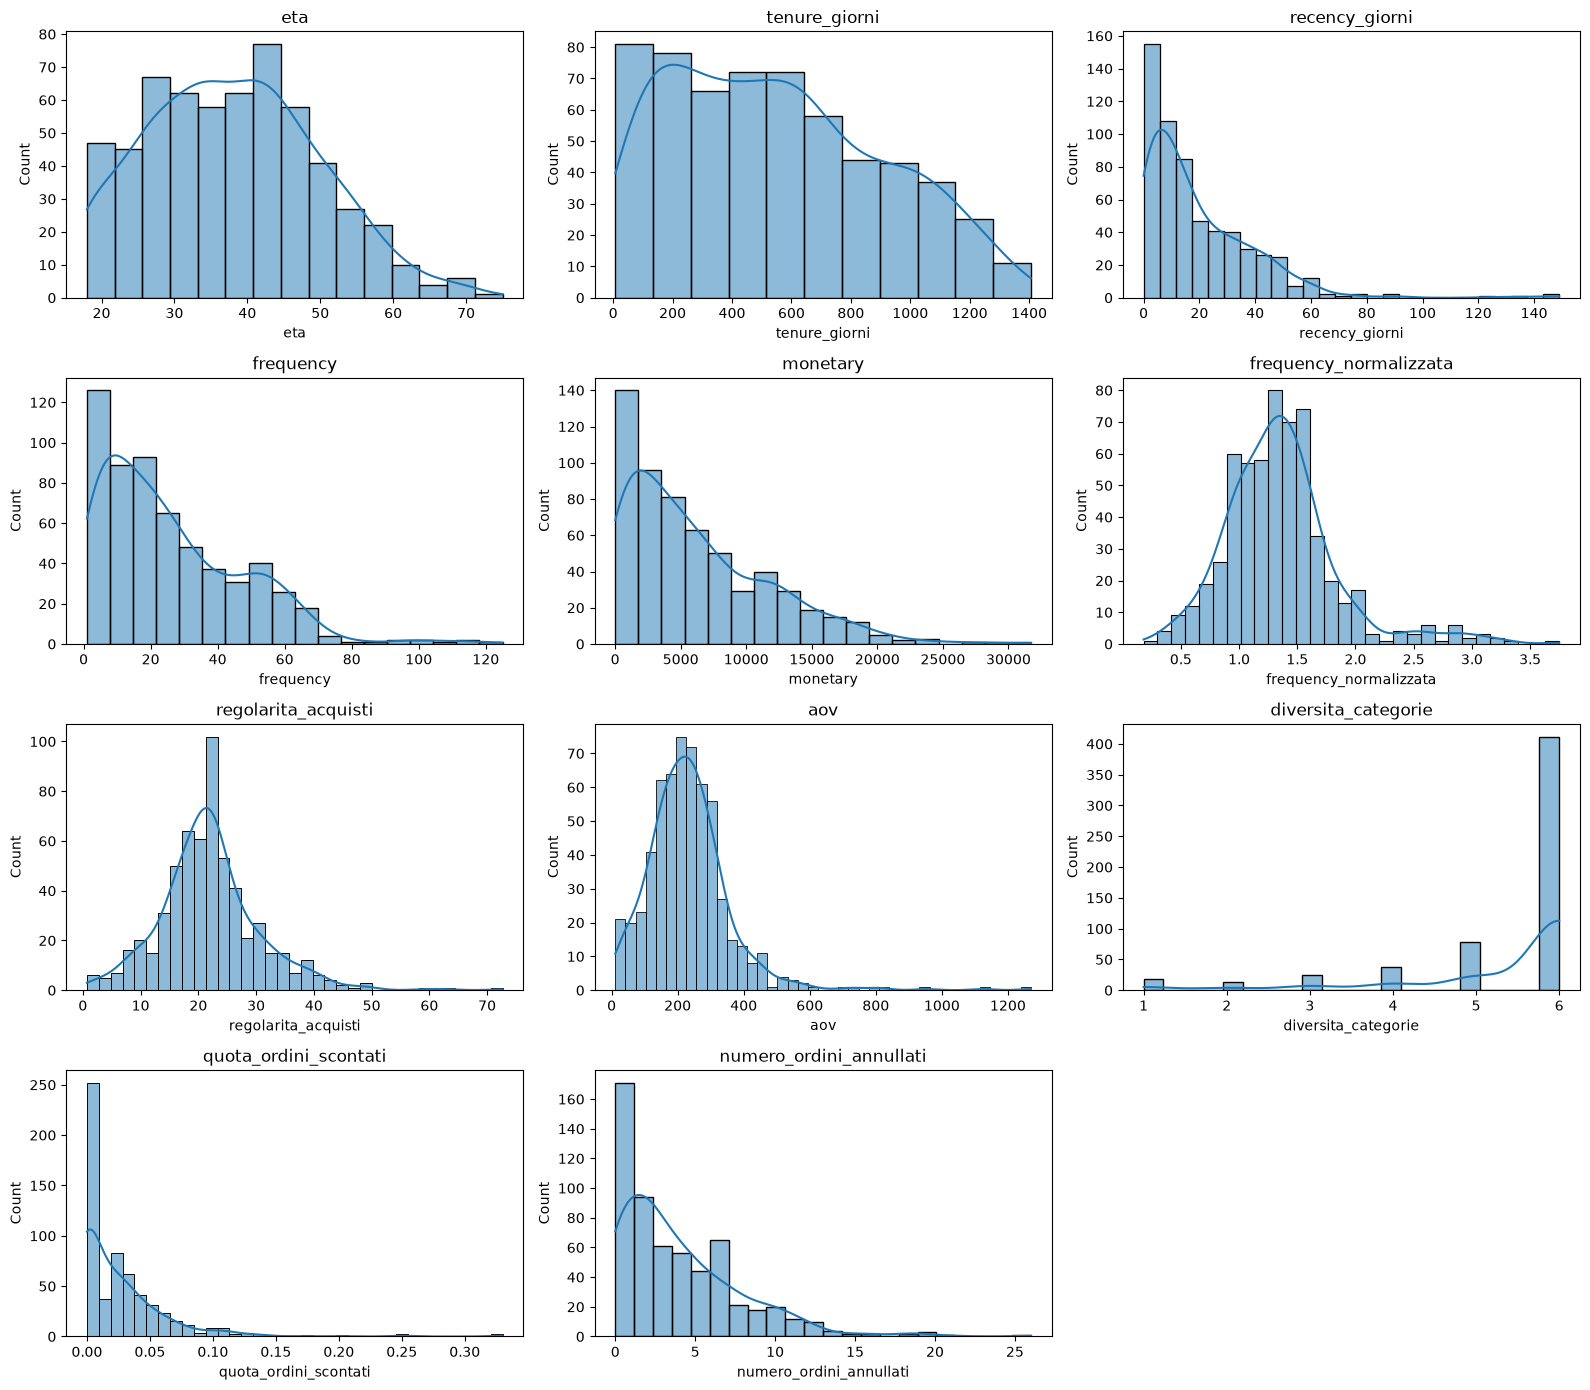

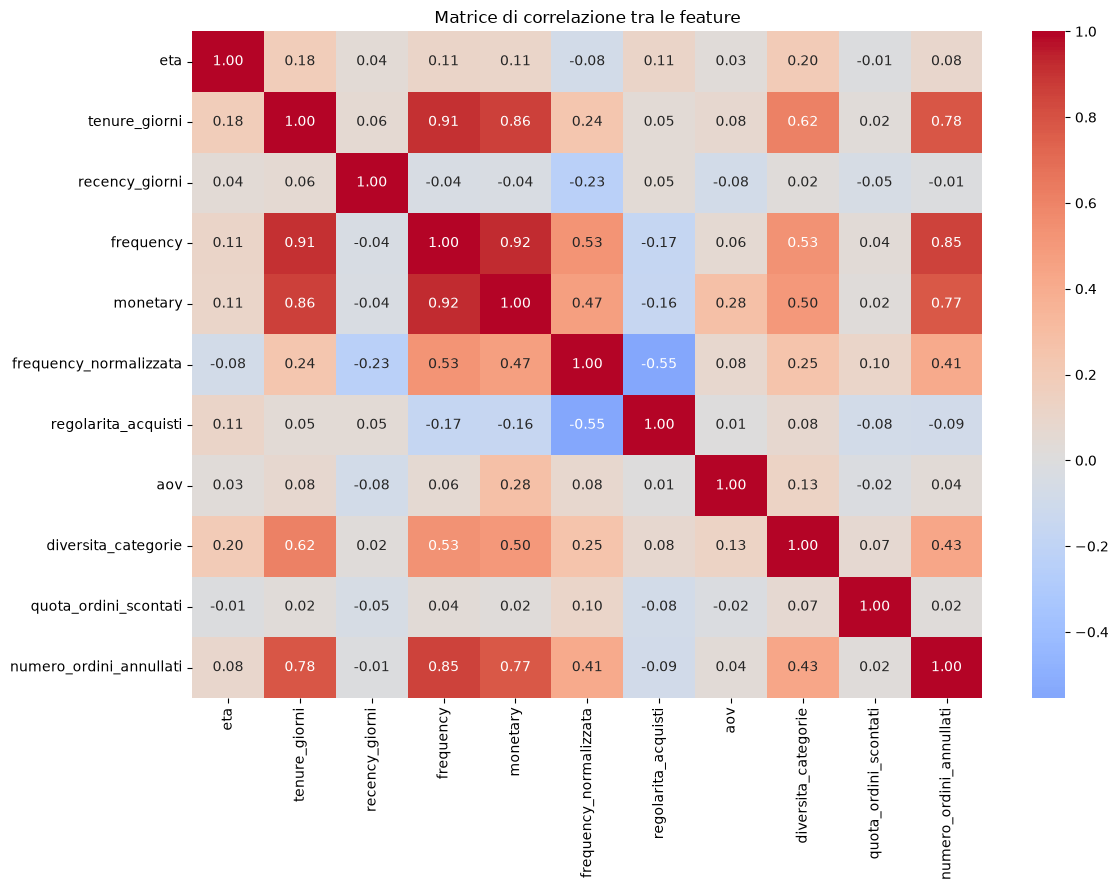


EDA completata. Controlla i grafici salvati: eda_distribuzioni.png, eda_correlazioni.png


In [35]:
"""
FASE 3 - Clustering clienti
STEP 1: Caricamento + Analisi Esplorativa (EDA)

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# ============================================================
# CARICAMENTO
# ============================================================

df = pd.read_csv('clustering.csv', sep=';')

print("=" * 60)
print("INFO GENERALI")
print("=" * 60)
print(f"Righe: {len(df)}  |  Colonne: {len(df.columns)}")
df.info()

# ============================================================
# CORREZIONE: colonne numeriche rimaste 'str' per la virgola
# decimale (dovuta alle impostazioni regionali italiane di SSMS
# in fase di esportazione del CSV)
# ============================================================
colonne_da_correggere = [
    "monetary", "frequency_normalizzata", "regolarita_acquisti",
    "aov", "quota_ordini_scontati"
]
for col in colonne_da_correggere:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="raise"
    )

print("\n" + "=" * 60)
print("TIPI DOPO LA CORREZIONE")
print("=" * 60)
df[colonne_da_correggere].info()

# ============================================================
# EDA - valori mancanti
# ============================================================
print("\n" + "=" * 60)
print("VALORI MANCANTI PER COLONNA")
print("=" * 60)
print(df.isnull().sum())

# ============================================================
# EDA - statistiche descrittive (colonne numeriche)
# ============================================================
print("\n" + "=" * 60)
print("STATISTICHE DESCRITTIVE")
print("=" * 60)
print(df.describe())

# ============================================================
# EDA - colonne categoriche: quanti valori distinti, quali
# ============================================================
print("\n" + "=" * 60)
print("COLONNE CATEGORICHE")
print("=" * 60)
colonne_categoriche = ["paese", "sesso", "metodo_pagamento_prevalente"]
for col in colonne_categoriche:
    print(f"\n{col}:")
    print(df[col].value_counts())

# ============================================================
# EDA - distribuzioni delle feature numeriche principali
# ============================================================
feature_numeriche = [
    "eta", "tenure_giorni", "recency_giorni", "frequency", "monetary",
    "frequency_normalizzata", "regolarita_acquisti", "aov",
    "diversita_categorie", "quota_ordini_scontati", "numero_ordini_annullati"
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(feature_numeriche):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(feature_numeriche), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("eda_distribuzioni.png", dpi=120, bbox_inches="tight")
plt.show()

# ============================================================
# EDA - matrice di correlazione (solo numeriche)
# ============================================================
plt.figure(figsize=(12, 9))
corr = df[feature_numeriche].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra le feature")
plt.tight_layout()
plt.savefig("eda_correlazioni.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nEDA completata. Controlla i grafici salvati: eda_distribuzioni.png, eda_correlazioni.png")

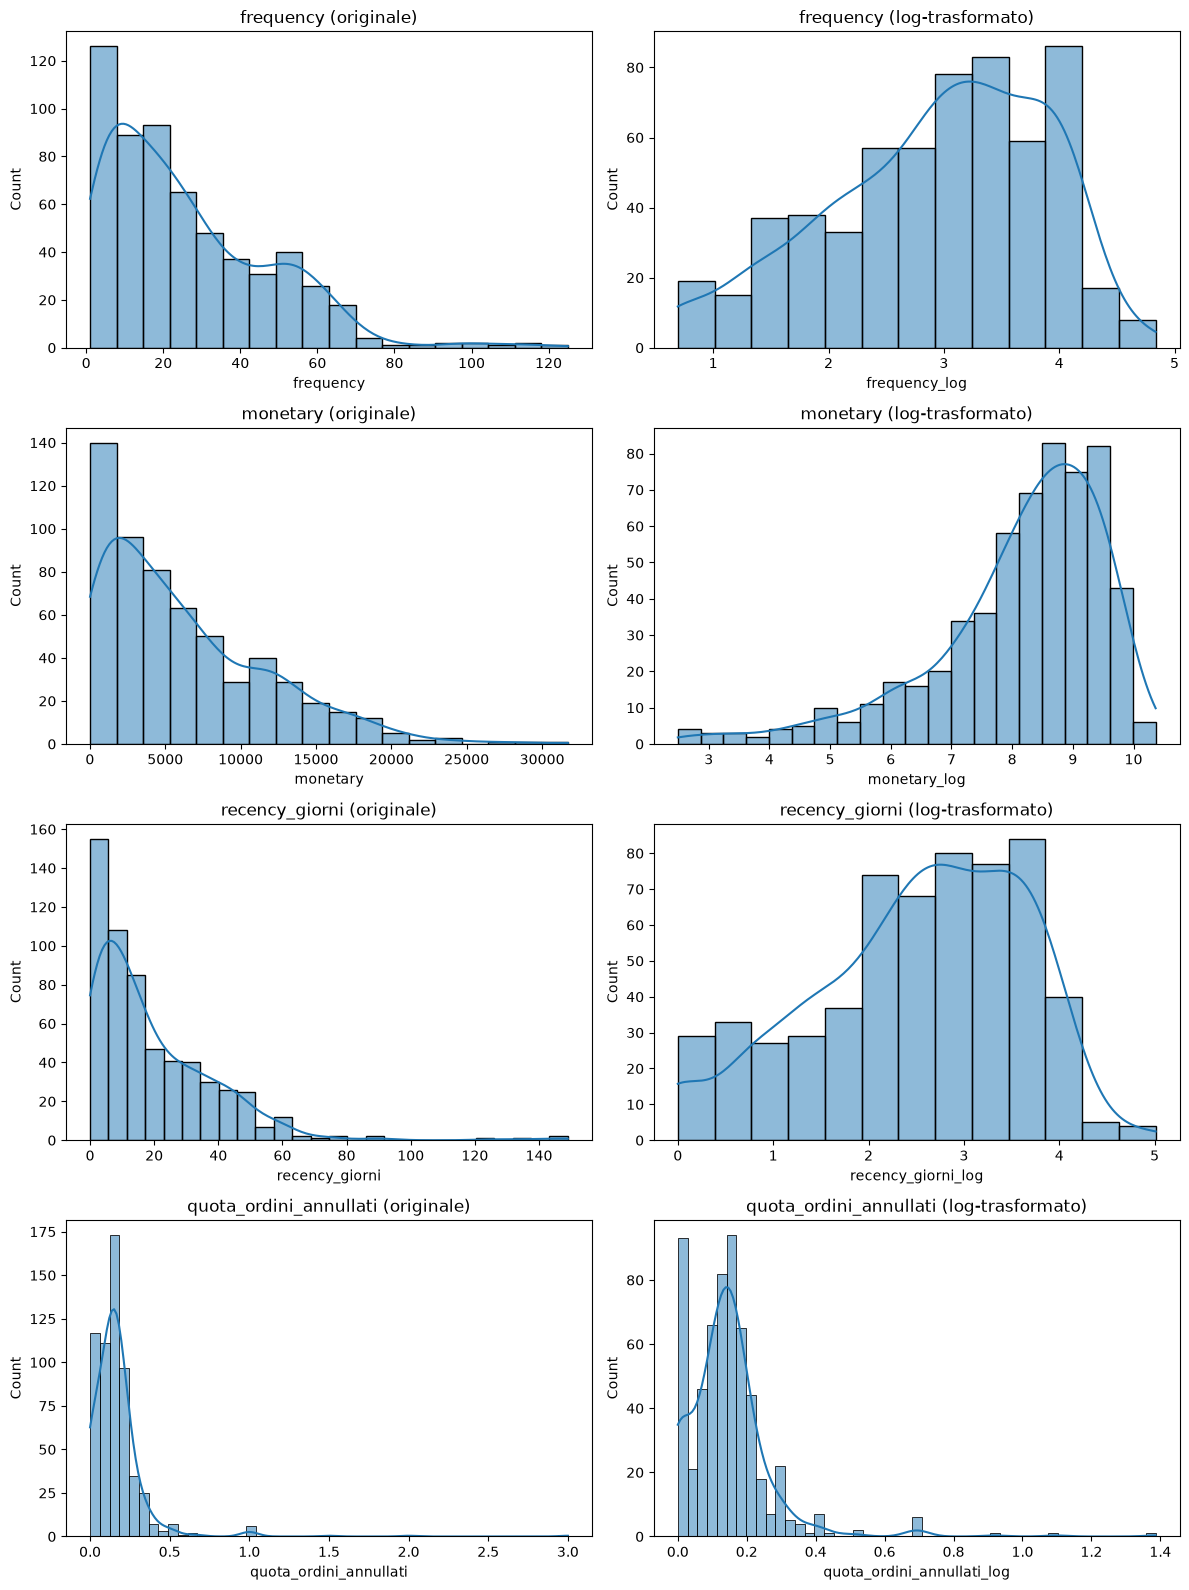


Colonne nella matrice di clustering: ['eta', 'sesso', 'tenure_giorni', 'frequency_normalizzata', 'regolarita_acquisti', 'regolarita_non_calcolabile', 'aov', 'diversita_categorie', 'quota_ordini_scontati', 'frequency_log', 'monetary_log', 'recency_giorni_log', 'quota_ordini_annullati_log']
Numero totale di colonne dopo l'encoding: 13


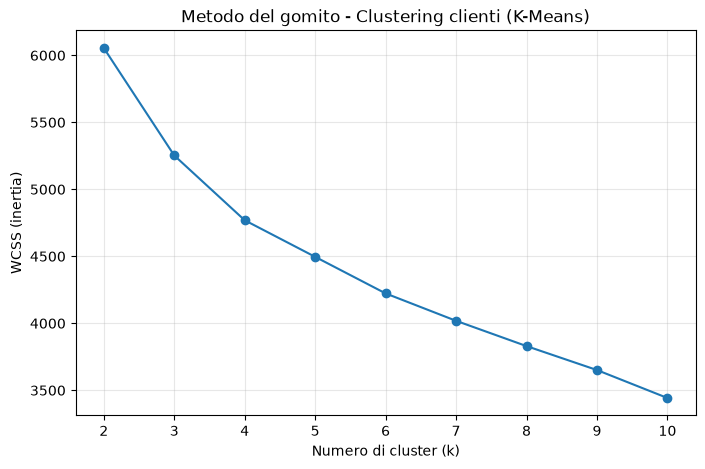


Valori WCSS per ogni k:
  k=2: 6054.8
  k=3: 5252.6
  k=4: 4769.0
  k=5: 4496.0
  k=6: 4223.1
  k=7: 4018.5
  k=8: 3829.8
  k=9: 3651.0
  k=10: 3442.4

Guarda il grafico 'metodo_del_gomito.png': scegli il k dove la curva
smette di scendere ripidamente (il "gomito") prima di procedere.


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# ============================================================
# STEP 1: CORREZIONE - numero_ordini_annullati -> rapporto
# (invece del conteggio grezzo, per rimuovere la ridondanza
# con tenure/frequency che avevamo scoperto nell'EDA)
# ============================================================
df["quota_ordini_annullati"] = df["numero_ordini_annullati"] / df["frequency"]
df = df.drop(columns=["numero_ordini_annullati"])

# ============================================================
# STEP 2: LOG-TRANSFORM sulle feature right-skewed
# (log1p invece di log, per gestire correttamente eventuali zeri)
# ============================================================
colonne_da_trasformare = ["frequency", "monetary", "recency_giorni", "quota_ordini_annullati"]

for col in colonne_da_trasformare:
    df[f"{col}_log"] = np.log1p(df[col])

# Confronto visivo prima/dopo, per verificare che la trasformazione abbia funzionato
fig, axes = plt.subplots(len(colonne_da_trasformare), 2, figsize=(12, 4 * len(colonne_da_trasformare)))
for i, col in enumerate(colonne_da_trasformare):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} (originale)")
    sns.histplot(df[f"{col}_log"], kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} (log-trasformato)")
plt.tight_layout()
plt.savefig("confronto_log_transform.png", dpi=120, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 3: SEPARAZIONE identificativi / feature
# ============================================================
identificativi = df[["customer_key", "nome_completo"]].copy()

# Le colonne originali (pre log-transform) vengono escluse dalla matrice
# finale di clustering, sostituite dalle rispettive versioni _log.
# "metodo_pagamento_prevalente" e "paese" vengono esclusi perche'
# entrambi (in due tentativi separati) dominavano il calcolo delle
# distanze, generando cluster definiti quasi al 100% da una singola
# categoria invece che dal comportamento d'acquisto - restano
# comunque in df per essere analizzati DOPO il clustering.
colonne_da_escludere = ["customer_key", "nome_completo", "metodo_pagamento_prevalente", "paese"] + colonne_da_trasformare

X = df.drop(columns=colonne_da_escludere)

print(f"\nColonne nella matrice di clustering: {X.columns.tolist()}")

# ============================================================
# STEP 4: ENCODING delle colonne categoriche
# ============================================================
# "zona" (derivata da "paese") NON entra piu' nella matrice X -
# la ricreo pero' in df, per poterla comunque analizzare dopo,
# come gia' avviene per sesso e metodo di pagamento
paesi_europa = ['Francia', 'Germania', 'Spagna', 'Portogallo', 'Paesi Bassi', 'Belgio', 'Polonia', 'Austria']
paesi_mondo = ['Stati Uniti', 'Regno Unito', 'Brasile', 'Giappone', 'Canada', 'Australia']

def classifica_zona(paese):
    if paese == 'Italia':
        return 'Italia'
    elif paese in paesi_europa:
        return 'Europa'
    elif paese in paesi_mondo:
        return 'Mondo'
    else:
        return 'Altro'

df["zona"] = df["paese"].apply(classifica_zona)

# L'unica colonna categorica rimasta nella matrice di clustering e' "sesso"
X["sesso"] = X["sesso"].map({"Maschio": 0, "Femmina": 1})

print(f"Numero totale di colonne dopo l'encoding: {X.shape[1]}")

# ============================================================
# STEP 5: STANDARDIZZAZIONE
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 6: METODO DEL GOMITO (versione manuale)
# NOTA: yellowbrick non e' compatibile con Python 3.12+ (dipende
# da 'distutils', rimosso dalla libreria standard) - usiamo quindi
# il metodo manuale, ugualmente valido secondo la guida ML
# ============================================================
wcss = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss, marker="o")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("WCSS (inertia)")
plt.title("Metodo del gomito - Clustering clienti (K-Means)")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.savefig("metodo_del_gomito.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nValori WCSS per ogni k:")
for k, w in zip(k_range, wcss):
    print(f"  k={k}: {w:.1f}")

print("\nGuarda il grafico 'metodo_del_gomito.png': scegli il k dove la curva")
print("smette di scendere ripidamente (il \"gomito\") prima di procedere.")

Distribuzione clienti per cluster:
cluster
0     34
1    207
2    225
3    121
Name: count, dtype: int64

Varianza spiegata dalle 2 componenti PCA: 45.3%


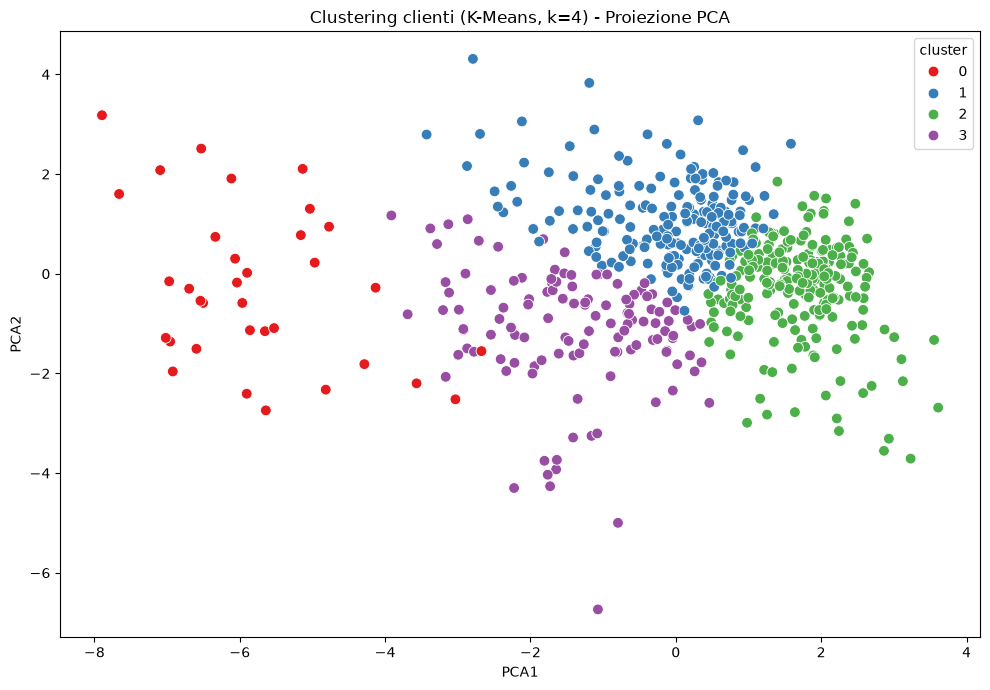


PROFILO MEDIO DI OGNI CLUSTER (feature numeriche)
           eta  tenure_giorni  recency_giorni  frequency  monetary  frequency_normalizzata  regolarita_acquisti     aov  diversita_categorie  \
cluster                                                                                                                                        
0        32.29          53.74           18.03       1.44    325.95                    0.94                21.95  192.42                 1.65   
1        41.04         479.78           24.57      17.39   4015.52                    1.07                29.19  237.58                 5.66   
2        38.98         882.28           17.24      47.68  11686.90                    1.64                19.28  248.98                 6.00   
3        32.40         175.69           14.47       7.71   1540.82                    1.43                14.52  204.66                 4.66   

         quota_ordini_scontati  quota_ordini_annullati  
cluster                    

C:\Users\Carlo Alberto\AppData\Local\Temp\ipykernel_3520\2378351705.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="cluster", palette="Set1")


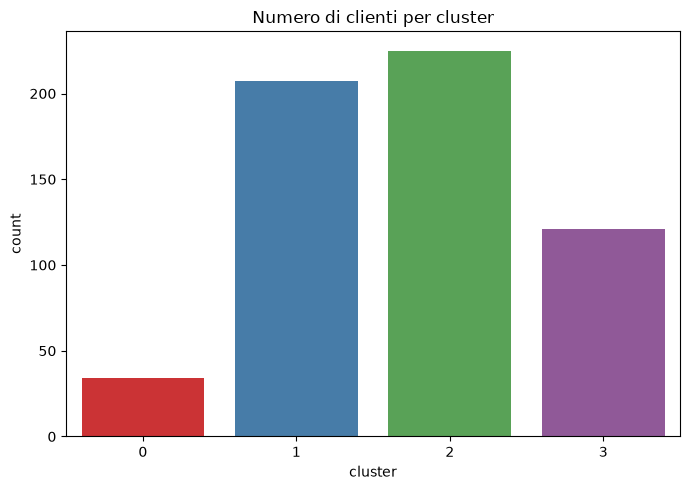


Riassunto salvato in 'clustering_riassunto_cluster.csv'
Grafici salvati: clustering_pca.png, clustering_countplot.png


In [37]:
from sklearn.decomposition import PCA

# ============================================================
# APPLICAZIONE K-MEANS (k=4)
# ============================================================
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(f"Distribuzione clienti per cluster:")
print(df["cluster"].value_counts().sort_index())

# ============================================================
# PCA per visualizzazione 2D
# ============================================================
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

print(f"\nVarianza spiegata dalle 2 componenti PCA: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="cluster", palette="Set1", s=60)
plt.title(f"Clustering clienti (K-Means, k={k}) - Proiezione PCA")
plt.tight_layout()
plt.savefig("clustering_pca.png", dpi=120, bbox_inches="tight")
plt.show()

# ============================================================
# INTERPRETAZIONE - Tabella riassuntiva
# ============================================================
feature_da_riassumere = [
    "eta", "tenure_giorni", "recency_giorni", "frequency", "monetary",
    "frequency_normalizzata", "regolarita_acquisti", "aov",
    "diversita_categorie", "quota_ordini_scontati", "quota_ordini_annullati"
]

riassunto = df.groupby("cluster")[feature_da_riassumere].mean().round(2)
print("\n" + "=" * 80)
print("PROFILO MEDIO DI OGNI CLUSTER (feature numeriche)")
print("=" * 80)
print(riassunto)

# ============================================================
# INTERPRETAZIONE - Distribuzione delle categoriche per cluster
# (zona, sesso, metodo di pagamento) - non comparivano nella
# tabella sopra perche' sono testo, non numeri da mediare.
# "zona" e' gia' presente in df, creata dallo script di preparazione.
# ============================================================
for col in ["zona", "sesso", "metodo_pagamento_prevalente"]:
    print("\n" + "=" * 80)
    print(f"DISTRIBUZIONE DI '{col}' PER CLUSTER (% sul totale di ogni cluster)")
    print("=" * 80)
    tabella = pd.crosstab(df["cluster"], df[col], normalize="index").round(3) * 100
    print(tabella)
    tabella.to_csv(f"clustering_riassunto_{col}.csv")

print("\nRiassunti categorici salvati: clustering_riassunto_zona.csv, "
      "clustering_riassunto_sesso.csv, clustering_riassunto_metodo_pagamento_prevalente.csv")

# Conteggio clienti per cluster (per capire se sono bilanciati)
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="cluster", palette="Set1")
plt.title("Numero di clienti per cluster")
plt.tight_layout()
plt.savefig("clustering_countplot.png", dpi=120, bbox_inches="tight")
plt.show()

# Salvo il riassunto anche su file per consultazione comoda
riassunto.to_csv("clustering_riassunto_cluster.csv")
print("\nRiassunto salvato in 'clustering_riassunto_cluster.csv'")
print("Grafici salvati: clustering_pca.png, clustering_countplot.png")